In [ ]:
!pip install tensorflow pandas matplotlib scikit-learn
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

In [ ]:
#Load the dataset

df = pd.read_csv('CombinedData.csv')
df = df.dropna(subset=['statement', 'status']).copy()
x = df['statement'].astype(str)
y = df['status']

In [ ]:
#endcode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

In [ ]:
#x_train, x_test, y_train, y_test = train_test_split(
x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y_encoded, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_encoded
    )

In [ ]:
max_words = 10000
max_len = 32

tokenizer = Tokenizer(
num_words=max_words,
oov_token='<OOV>'
)
tokenizer.fit_on_texts(x_train)
    
x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)
    
# Padding so every sample has the same sequence length
x_train_pad = pad_sequences(
    x_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)
x_test_pad = pad_sequences(
    x_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

vocab_size = min(max_words, len(tokenizer.word_index) + 1)


In [ ]:
class RandomForest_Model:
    def __init__(self, vocab_size, max_len, hidden_size, num_classes):
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.hidden_size = hidden_size
        self.num_classes = num_classes
        self.model = self.build_model()
            
    def build_model(self):
        model = Sequential([
            
            ])
        model.compile(
            
            )
        return model


In [ ]:
history = model.fit(
    
)

Epoch 1/10
807/807 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.5705 - loss: 1.0859 - val_accuracy: 0.6291 - val_loss: 0.9170
Epoch 2/10
807/807 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6591 - loss: 0.8675 - val_accuracy: 0.6922 - val_loss: 0.7840
Epoch 3/10
807/807 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6981 - loss: 0.7782 - val_accuracy: 0.7123 - val_loss: 0.7369
Epoch 4/10
807/807 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7177 - loss: 0.7288 - val_accuracy: 0.7176 - val_loss: 0.7244
Epoch 5/10
807/807 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7334 - loss: 0.6888 - val_accuracy: 0.7146 - val_loss: 0.7318
Epoch 6/10
807/807 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7404 - loss: 0.6620 - val_accuracy: 0.7195 - val_loss: 0.7177
Epoch 7/10
807/807 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7522 - loss: 0.6360 - val_accuracy: 0.7147 - val_loss: 0.7250
Epoch 8/10
807/807 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7607 - loss: 0.6109 - 

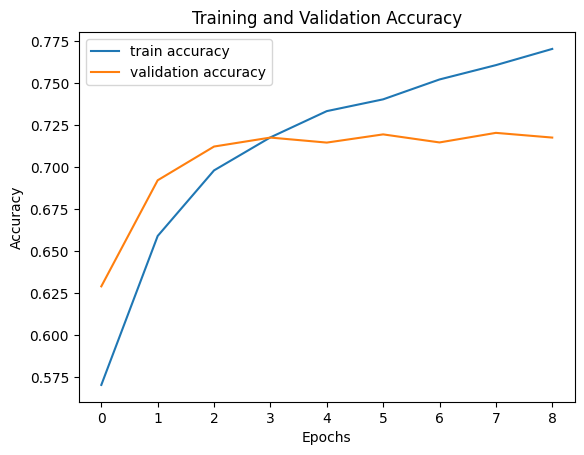

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()